# MODELING THE KINETICS OF THE CENTRAL DOGMA

### IMPORTS

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.integrate import odeint

### CREATING FUNCTIONS

#### CREATING A CENTRAL DOGMA ODE FUNCTION

In [2]:
def get_ode_derivatives(c, t, ktx, ktl):
    
    '''
    PURPOSE
    
        This function returns the first order derivatives of a concentration 
        vector given a time vector and rate constants. 
        
    ARGUMENTS
        
        c: a concentration vector in the form of (c_m(t), c_p(t)) describing 
           the concentration of mRNA and protein
        t: the time vector over which to step the function
        ktx: the transcription rate constant
        ktl: the translation rate constant
    
    RETURN
    
        dcdt: the first order derivatives of the concentration vector
    '''
    
    # Separate each species in the concentration vector
    c_m, c_p = c
    
    # Define the first order derivative for each species
    dcdt = [
        ktx, # reactions for c_m
        ktl*c_m # reactions for c_p
    ]
    return dcdt

#### CREATING AN ODE RUNNING WRAPPER FUNCTION

In [3]:
def run_ode(tx_time, tl_time, max_time=10):

    '''
    PURPOSE
    
        A wrapper for the ODE function that calculates all the necessray parameters 
        and makes the time vector given the transcription and translation rates
        and maximum time to run the ODE for in minutes
        
    ARGUMENTS
        
        tx_time: number of seconds it takes to make 1 mRNA via transcription
        tl_time: number of seconds it takes to make 1 protein via translation
        max_time: maximum length of time over which to run the function in minutes (default=10)
    
    RETURN
    
        ode_soln: the soluiton to the first order ODE with the given parameters
        ktx: transcription rate
        ktl: translation rate
        t: time vector in seconds
    '''
    
    # Calculate ktx and ktl
    ktx = 1./tx_time
    ktl = 1./tl_time
    
    # Define time vector
    t0 = 0 # initial time
    tn = max_time*60 # maximum time in seconds
    tsteps = 1000 # derivative steps to take
    t = np.linspace(t0,tn,tsteps) # create time vector spanning range with desired number of steps

    # initialize concentration parameters and array
    c_m = 0. #initial concentration of mRNA
    c_p = 0. #initial concentration of protein
    c0 = np.array([c_m, c_p])
    
    # call get_ode_derivatives function and solve
    ode_soln = sp.integrate.odeint(get_ode_derivatives, c0, t, args = (ktx, ktl))
    
    return ode_soln, ktx, ktl, t

#### CREATING AN ODE PLOTTING FUNCTION

In [4]:
def plot_ode(ode_soln, ktx, ktl, t, savefig='False'):
    
    '''
    PURPOSE
    
        A plotting function that takes the result of the central dogma ODE function 
        and plots the mRNA and protein concentrations over time.
        
    ARGUMENTS
        
        ode_soln: the soluiton to the first order ODE with the given parameters
        ktx: transcription rate
        ktl: translation rate
        t: time vector in seconds
        savefig: a flag (either True or False) indicating whether or not to save the figure
    
    RETURN
    
        None
    '''
    
    # Close any open plots
    #plt.close()
    
    # Plot mRNA and protein concentration over time
    plt.plot(t, ode_soln[:, 0],'b-', label='mRNA')
    plt.plot(t, ode_soln[:, 1],'g--', label='Protein')
    
    # Give plot some pretty labels and a legend
    plt.legend(loc='best')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Concentration')
    plt.title('ktx = {0} /sec, ktl = {1} /sec'.format(ktx, ktl))
    
    # Scale the axes to match that of the maximum value of x and y, respectively
    plt.xlim(0, max(t))
    plt.ylim(0, max(max(ode_soln[:, 0]),max(ode_soln[:, 1])))
   
    # Save figure if indicated
    if savefig:
        
        plt.savefig('{0}_{1}.png'.format(ktx, ktl), dpi=300)
    
    # Show figure
    plt.show()
    
    return

### FUNCTION CALLS

#### EXAMPLE

This is an example of how to run the functions above such taht you'll get an output of the graphs you need. When you do this on your homework, you may simply copy this and edit this code to iterate over all possible combinations of transcription (<code>tx</code>) and translation (<code>tl</code>) rates you're asked for. Please look over the above functions so you understand what they're doing at a high level, but you do not need to edit any of them for your homewokr--you'll only need to (slightly) modify the code below.

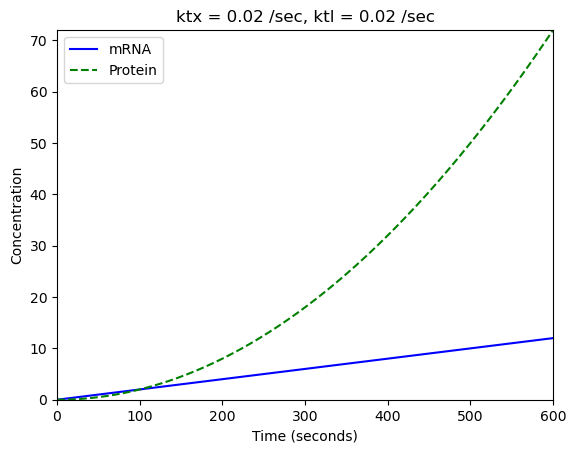

In [5]:
# Initialize mRNA and protein times
mRNA_rates = [50] # time to make 1 mRNA
protein_rates = [50] # time to make 1 protein

# Call ODE function for each combination of mRNA and protein rates
for tx_time in mRNA_rates:
    for tl_time in protein_rates:
        ode_soln, ktx, ktl, t = run_ode(tx_time, tl_time, max_time=10)
        plot_ode(ode_soln, ktx, ktl, t, savefig='True')